In [59]:
import json
import pandas as pd
import matplotlib.pyplot as plt

def get_trace_duration_from_root(spans):
    # Find the root span (span with no parent)
    root_span = None
    for span in spans:
        if not span.get('parentSpanID') or span.get('parentSpanID') == '':
            root_span = span
            break
    
    if root_span:
        return root_span['duration']  # Duration in microseconds
    return None

def process_trace_file(filename):
    """
    Load a JSON trace file and extract durations of spans 0 and 6.
    Returns a DataFrame with trigger, dispatcher, and total durations in milliseconds.
    """
    with open(filename) as f:
        data = json.load(f)
    
    results = []
    for trace in data['data']:
        trace_id = trace['traceID']
        duration = get_trace_duration_from_root(trace['spans'])
        print(duration)
        results.append({
                'traceID': trace_id,
                'total_duration_ms': '' 
            })
    return pd.DataFrame(results)

# Create DataFrame for High traces
df_high = process_trace_file('traces-1755680292126.json')

for span in spans:
        start_time = span['startTime']
        end_time = start_time + span['duration']
        
        earliest_start = min(earliest_start, start_time)
        latest_end = max(latest_end, end_time)
df_high.head()


1166
1056
3249
1518
1492
854
1194
911
1023
1258
876
1004
1301
1206
974
994
1002
1301
885
899


NameError: name 'spans' is not defined


Trace duration statistics:
Mean duration: 3.31ms
Median duration: 3.55ms
Min duration: 0.26ms
Max duration: 22.86ms


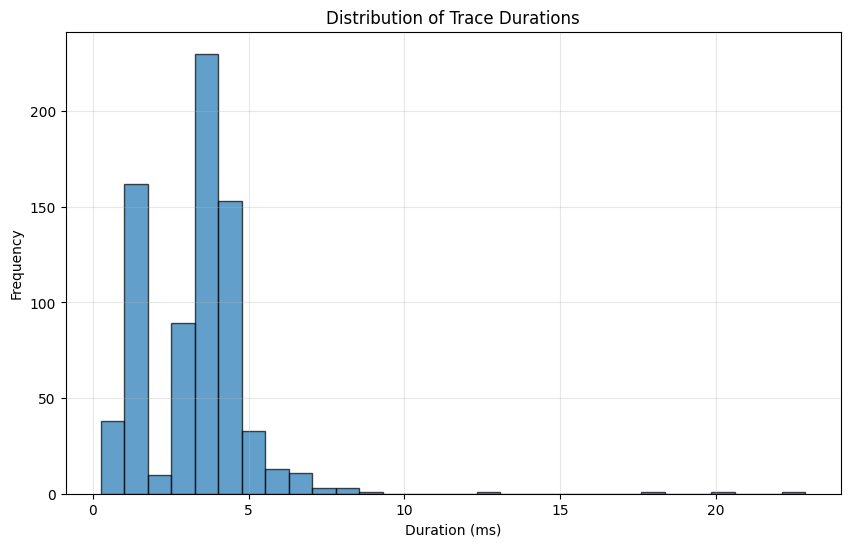

In [64]:
import json
import pandas as pd
import matplotlib.pyplot as plt

def get_trace_duration_from_root(spans):
    """Find the root span and return its duration"""
    root_span = None
    for span in spans:
        if not span.get('parentSpanID') or span.get('parentSpanID') == '':
            root_span = span
            break
    
    if root_span:
        return root_span['duration']  # Duration in microseconds
    return None

def calculate_trace_duration_from_all_spans(spans):
    """Calculate trace duration from earliest start to latest end across all spans"""
    if not spans:
        return 0
    
    earliest_start = float('inf')
    latest_end = 0
    
    for span in spans:
        start_time = span['startTime']
        end_time = start_time + span['duration']
        
        earliest_start = min(earliest_start, start_time)
        latest_end = max(latest_end, end_time)
    
    return latest_end - earliest_start

def process_trace_file(filename):
    """
    Load a JSON trace file and extract trace durations.
    Returns a DataFrame with trace IDs and total durations in milliseconds.
    """
    with open(filename) as f:
        data = json.load(f)
    
    results = []
    for trace in data['data']:
        trace_id = trace['traceID']
        spans = trace['spans']
        
        # Method 1: Get duration from root span
        root_duration = get_trace_duration_from_root(spans)
        
        # Method 2: Calculate from all spans (alternative/backup method)
        calculated_duration = calculate_trace_duration_from_all_spans(spans)
        
        # Convert microseconds to milliseconds
        root_duration_ms = root_duration / 1000 if root_duration else None
        calculated_duration_ms = calculated_duration / 1000 if calculated_duration else None
        
        print(f"Trace {trace_id}: Root duration = {root_duration_ms}ms, Calculated duration = {calculated_duration_ms}ms")
        
        results.append({
            'traceID': trace_id,
            'root_duration_ms': root_duration_ms,
            'calculated_duration_ms': calculated_duration_ms,
            'total_duration_ms': root_duration_ms or calculated_duration_ms  # Use root, fallback to calculated
        })
    
    return pd.DataFrame(results)

# Process the trace file
try:
    
    # Basic statistics
    print(f"\nTrace duration statistics:")
    print(f"Mean duration: {df_high['total_duration_ms'].mean():.2f}ms")
    print(f"Median duration: {df_high['total_duration_ms'].median():.2f}ms")
    print(f"Min duration: {df_high['total_duration_ms'].min():.2f}ms")
    print(f"Max duration: {df_high['total_duration_ms'].max():.2f}ms")
    
    # Plot histogram of durations
    plt.figure(figsize=(10, 6))
    plt.hist(df_high['total_duration_ms'].dropna(), bins=30, edgecolor='black', alpha=0.7)
    plt.xlabel('Duration (ms)')
    plt.ylabel('Frequency')
    plt.title('Distribution of Trace Durations')
    plt.grid(True, alpha=0.3)
    plt.show()
    
except FileNotFoundError:
    print("File 'traces-1755680292126.json' not found. Please check the filename and path.")
except json.JSONDecodeError:
    print("Error parsing JSON file. Please check if the file is valid JSON.")
except Exception as e:
    print(f"An error occurred: {e}")

Request 1 (Trace ffa004e231f7bd9e07dc08050ab8d2c2):
  Root span duration: 1.166ms
  Span 5 method duration: 7.629ms
  Time to span 5 start: 0.0ms
  Span 5 duration: 7.629ms

Request 2 (Trace ce39b05d89c4cbe21e2e16441da2a16b):
  Root span duration: 1.056ms
  Span 5 method duration: 4.617ms
  Time to span 5 start: 0.0ms
  Span 5 duration: 4.617ms

Request 3 (Trace 438f574e5ef8358d8c96357e629270d7):
  Root span duration: 3.249ms
  Span 5 method duration: 6.399ms
  Time to span 5 start: 0.0ms
  Span 5 duration: 6.399ms

Request 4 (Trace 36792d99747a9a681675438fe4b2e680):
  Root span duration: 1.518ms
  Span 5 method duration: 4.152ms
  Time to span 5 start: 0.0ms
  Span 5 duration: 4.152ms

Request 5 (Trace 832043b3153bf2085cdf82149bf43314):
  Root span duration: 1.492ms
  Span 5 method duration: 4.666ms
  Time to span 5 start: 0.0ms
  Span 5 duration: 4.666ms

Request 6 (Trace 7fc9d26876a52280c9c5b5e43bd499d9):
  Root span duration: 0.854ms
  Span 5 method duration: 3.883ms
  Time to span

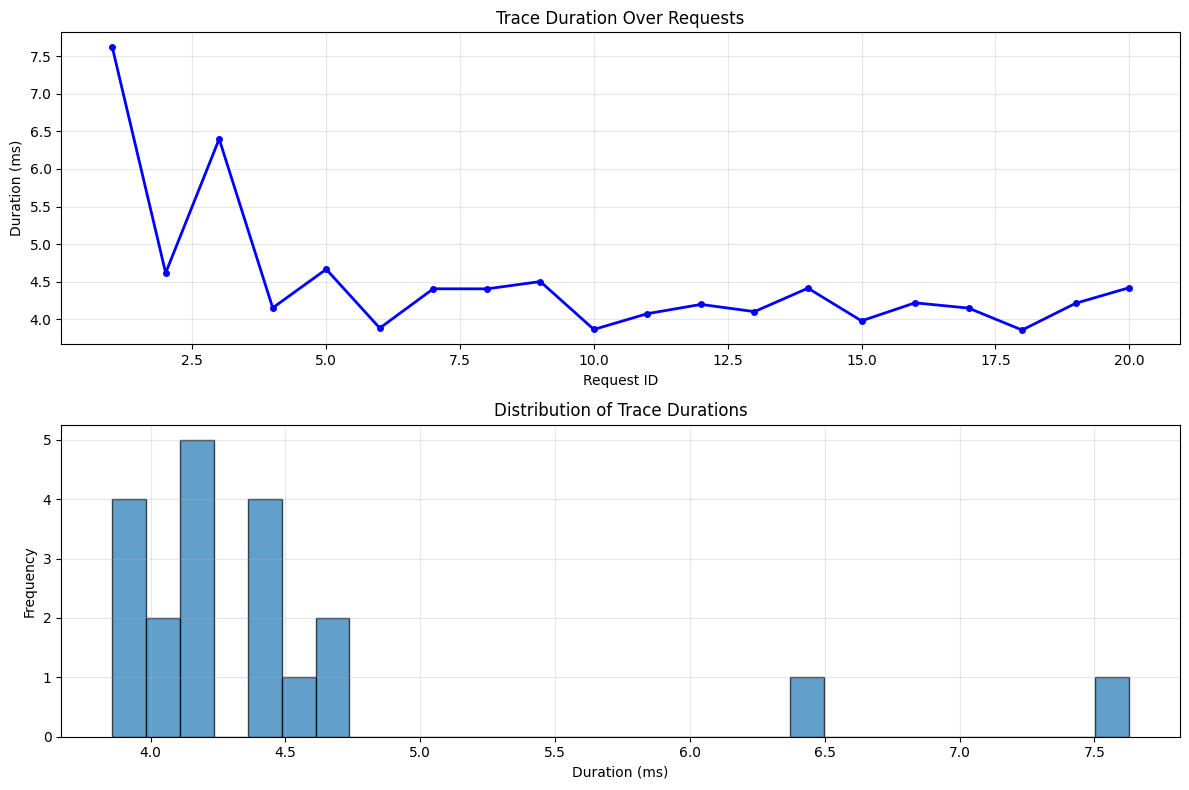

In [65]:
import json
import pandas as pd
import matplotlib.pyplot as plt

def get_trace_duration_from_root(spans):
    """Find the root span and return its duration"""
    root_span = None
    for span in spans:
        if not span.get('parentSpanID') or span.get('parentSpanID') == '':
            root_span = span
            break
    
    if root_span:
        return root_span['duration']  # Duration in microseconds
    return None

def calculate_duration_with_span5(spans):
    """
    Calcola la durata come: (inizio traccia - inizio span 5) + durata span 5
    """
    if len(spans) < 6:  # Assicurati che esista lo span 5 (indice 5)
        return None
    
    # Trova il tempo di inizio più precoce (inizio traccia)
    trace_start = min(span['startTime'] for span in spans)
    
    # Prendi lo span 5 (indice 5)
    span_5 = spans[5]
    span_5_start = span_5['startTime']
    span_5_duration = span_5['duration']
    
    # Calcola: (inizio traccia → inizio span 5) + durata span 5
    duration = (span_5_start - trace_start) + span_5_duration
    
    return duration

def process_trace_file(filename):
    """
    Load a JSON trace file and extract trace durations.
    Returns a DataFrame with request IDs, trace IDs and total durations in milliseconds.
    """
    with open(filename) as f:
        data = json.load(f)
    
    results = []
    for request_id, trace in enumerate(data['data'], 1):  # Start counting from 1
        trace_id = trace['traceID']
        spans = trace['spans']
        
        # Method 1: Get duration from root span
        root_duration = get_trace_duration_from_root(spans)
        
        # Method 2: Calculate using span 5 method
        span5_duration = calculate_duration_with_span5(spans)
        
        # Convert microseconds to milliseconds
        root_duration_ms = root_duration / 1000 if root_duration else None
        span5_duration_ms = span5_duration / 1000 if span5_duration else None
        
        print(f"Request {request_id} (Trace {trace_id}):")
        print(f"  Root span duration: {root_duration_ms}ms")
        print(f"  Span 5 method duration: {span5_duration_ms}ms")
        
        # Informazioni aggiuntive sullo span 5
        if len(spans) >= 6:
            span_5 = spans[5]
            trace_start = min(span['startTime'] for span in spans)
            time_to_span5 = (span_5['startTime'] - trace_start) / 1000  # in ms
            span5_own_duration = span_5['duration'] / 1000  # in ms
            print(f"  Time to span 5 start: {time_to_span5}ms")
            print(f"  Span 5 duration: {span5_own_duration}ms")
        print()
        
        results.append({
            'request_id': request_id,
            'traceID': trace_id,
            'root_duration_ms': root_duration_ms,
            'span5_method_duration_ms': span5_duration_ms,
            'total_duration_ms': span5_duration_ms or root_duration_ms  # Preferisce il metodo span 5
        })
    
    return pd.DataFrame(results)

# Process the trace file
try:
    df_high = process_trace_file('traces-1755680292126.json')
    print("\nDataFrame created successfully:")
    print(df_high.head())
    
    # Basic statistics
    print(f"\nTrace duration statistics:")
    print(f"Mean duration: {df_high['total_duration_ms'].mean():.2f}ms")
    print(f"Median duration: {df_high['total_duration_ms'].median():.2f}ms")
    print(f"Min duration: {df_high['total_duration_ms'].min():.2f}ms")
    print(f"Max duration: {df_high['total_duration_ms'].max():.2f}ms")
    
    # Plot line graph of durations over request IDs
    plt.figure(figsize=(12, 8))
    
    # Create subplot layout
    plt.subplot(2, 1, 1)
    plt.plot(df_high['request_id'], df_high['total_duration_ms'], 'b-o', linewidth=2, markersize=4)
    plt.xlabel('Request ID')
    plt.ylabel('Duration (ms)')
    plt.title('Trace Duration Over Requests')
    plt.grid(True, alpha=0.3)
    
    # Plot histogram of durations
    plt.subplot(2, 1, 2)
    plt.hist(df_high['total_duration_ms'].dropna(), bins=30, edgecolor='black', alpha=0.7)
    plt.xlabel('Duration (ms)')
    plt.ylabel('Frequency')
    plt.title('Distribution of Trace Durations')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
except FileNotFoundError:
    print("File 'traces-1755680292126.json' not found. Please check the filename and path.")
except json.JSONDecodeError:
    print("Error parsing JSON file. Please check if the file is valid JSON.")
except Exception as e:
    print(f"An error occurred: {e}")

Request 1 (Trace e3723cdb079878be9f4ca6fcbe6c5050): Root duration = 3.45ms, Calculated duration = 6.145ms
Request 2 (Trace f4d38054d3d1dca8e6a726e68225c3ac): Root duration = 4.169ms, Calculated duration = 6.052ms
Request 3 (Trace decdde4ca5f0c96b7d15c581491f893c): Root duration = 3.629ms, Calculated duration = 6.37ms
Request 4 (Trace f2ed5af7f4be39e738ec289fb902b326): Root duration = 3.597ms, Calculated duration = 6.024ms
Request 5 (Trace b972b5e638f40aa579966169300dcf33): Root duration = 3.499ms, Calculated duration = 7.066ms
Request 6 (Trace 0a3359d64a7864062b141a922ad68bfe): Root duration = 4.264ms, Calculated duration = 7.389ms
Request 7 (Trace 27a693273e787b703965c59b7a3dc8ee): Root duration = 3.95ms, Calculated duration = 9.039ms
Request 8 (Trace 8a7f2da9eabc1d5d6d5413053bac4771): Root duration = 5.405ms, Calculated duration = 8.454ms
Request 9 (Trace 624b6bbcf052db9aa6a56e8a4c19f0cc): Root duration = 3.694ms, Calculated duration = 7.502ms
Request 10 (Trace 2acb115302230428a4a7b4

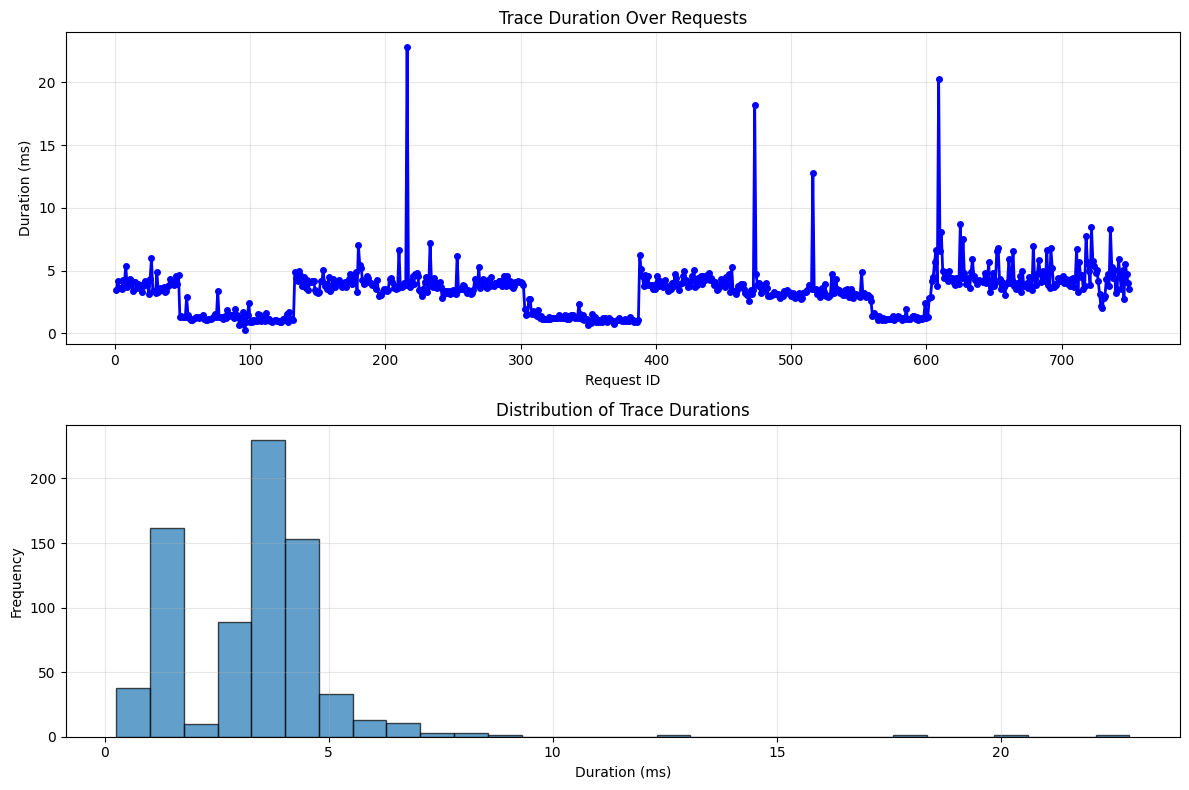

In [63]:
import json
import pandas as pd
import matplotlib.pyplot as plt

def get_trace_duration_from_root(spans):
    """Find the root span and return its duration"""
    root_span = None
    for span in spans:
        if not span.get('parentSpanID') or span.get('parentSpanID') == '':
            root_span = span
            break
    
    if root_span:
        return root_span['duration']  # Duration in microseconds
    return None

def calculate_trace_duration_from_all_spans(spans):
    """Calculate trace duration from earliest start to latest end across all spans"""
    if not spans:
        return 0
    
    earliest_start = float('inf')
    latest_end = 0
    
    for span in spans:
        start_time = span['startTime']
        end_time = start_time + span['duration']
        
        earliest_start = min(earliest_start, start_time)
        latest_end = max(latest_end, end_time)
    
    return latest_end - earliest_start

def process_trace_file(filename):
    """
    Load a JSON trace file and extract trace durations.
    Returns a DataFrame with request IDs, trace IDs and total durations in milliseconds.
    """
    with open(filename) as f:
        data = json.load(f)
    
    results = []
    for request_id, trace in enumerate(data['data'], 1):  # Start counting from 1
        trace_id = trace['traceID']
        spans = trace['spans']
        
        # Method 1: Get duration from root span
        root_duration = get_trace_duration_from_root(spans)
        
        # Method 2: Calculate from all spans (alternative/backup method)
        calculated_duration = calculate_trace_duration_from_all_spans(spans)
        
        # Convert microseconds to milliseconds
        root_duration_ms = root_duration / 1000 if root_duration else None
        calculated_duration_ms = calculated_duration / 1000 if calculated_duration else None
        
        print(f"Request {request_id} (Trace {trace_id}): Root duration = {root_duration_ms}ms, Calculated duration = {calculated_duration_ms}ms")
        
        results.append({
            'request_id': request_id,
            'traceID': trace_id,
            'root_duration_ms': root_duration_ms,
            'calculated_duration_ms': calculated_duration_ms,
            'total_duration_ms': root_duration_ms or calculated_duration_ms  # Use root, fallback to calculated
        })
    
    return pd.DataFrame(results)

# Process the trace file
try:
    df_high = process_trace_file('traces-1755613029848-edge-high.json')
    print("\nDataFrame created successfully:")
    print(df_high.head())
    
    # Basic statistics
    print(f"\nTrace duration statistics:")
    print(f"Mean duration: {df_high['total_duration_ms'].mean():.2f}ms")
    print(f"Median duration: {df_high['total_duration_ms'].median():.2f}ms")
    print(f"Min duration: {df_high['total_duration_ms'].min():.2f}ms")
    print(f"Max duration: {df_high['total_duration_ms'].max():.2f}ms")
    
    # Plot line graph of durations over request IDs
    plt.figure(figsize=(12, 8))
    
    # Create subplot layout
    plt.subplot(2, 1, 1)
    plt.plot(df_high['request_id'], df_high['total_duration_ms'], 'b-o', linewidth=2, markersize=4)
    plt.xlabel('Request ID')
    plt.ylabel('Duration (ms)')
    plt.title('Trace Duration Over Requests')
    plt.grid(True, alpha=0.3)
    
    # Plot histogram of durations
    plt.subplot(2, 1, 2)
    plt.hist(df_high['total_duration_ms'].dropna(), bins=30, edgecolor='black', alpha=0.7)
    plt.xlabel('Duration (ms)')
    plt.ylabel('Frequency')
    plt.title('Distribution of Trace Durations')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
except FileNotFoundError:
    print("File 'traces-1755680292126.json' not found. Please check the filename and path.")
except json.JSONDecodeError:
    print("Error parsing JSON file. Please check if the file is valid JSON.")
except Exception as e:
    print(f"An error occurred: {e}")